# Agente de Notas Fiscais

O agente responde perguntas sobre as notas guardadas em `invoices.db`, o banco que o `ingest.ipynb` gera. O esquema do banco vai na mensagem de sistema, e a única ferramenta roda consultas `SELECT`: o modelo decide quais consultas escrever e quantas, lê o resultado e responde. Um checkpointer guarda a conversa de cada thread.

In [1]:
# No Google Colab, descomente e rode uma vez.

# !pip install -q langchain langchain-openai langgraph

# import os
# from google.colab import userdata

# os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [2]:
import sqlite3

from IPython.display import Image

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.0)

DATABASE = "invoices.db"

## A ferramenta

O esquema é lido uma vez do próprio SQLite, com os `CREATE TABLE` de cada tabela, e vai direto para o prompt. Ele é pequeno e não muda durante a conversa, então uma ferramenta só para consultá-lo custaria uma volta do laço sem trazer nada novo.

In [4]:
with sqlite3.connect(DATABASE) as connection:
    SCHEMA = "\n\n".join(sql for (sql,) in connection.execute("SELECT sql FROM sqlite_master WHERE type = 'table'"))

print(SCHEMA)

CREATE TABLE "invoices" (
"file" TEXT,
  "seller" TEXT,
  "date" TEXT,
  "total" REAL,
  "issues" TEXT
)

CREATE TABLE "products" (
"file" TEXT,
  "name" TEXT,
  "quantity" REAL,
  "price" REAL
)


A ferramenta aceita só consultas que começam com `SELECT`, e a conexão abre com `mode=ro`, então mesmo uma consulta que escape da verificação não consegue escrever. O `execute` do `sqlite3` roda uma instrução por vez, o que barra um `DELETE` pendurado depois de um ponto e vírgula. Os erros voltam como texto, porque são uma observação que o modelo lê para corrigir a consulta.

In [5]:
@tool
def run_select(query: str) -> str:
    """Roda uma consulta SELECT no banco de notas fiscais e devolve até 50 linhas."""
    if not query.strip().lower().startswith("select"):
        return "erro: só consultas SELECT são permitidas"
    with sqlite3.connect(f"file:{DATABASE}?mode=ro", uri=True) as connection:
        try:
            cursor = connection.execute(query)
        except (sqlite3.Error, sqlite3.Warning) as error:
            return f"erro: {error}"
        columns = [column[0] for column in cursor.description]
        rows = cursor.fetchmany(50)
    return "\n".join([" | ".join(columns)] + [" | ".join(map(str, row)) for row in rows])

In [6]:
print(run_select.invoke({"query": "SELECT seller, total FROM invoices ORDER BY total DESC LIMIT 3"}))
print(run_select.invoke({"query": "DELETE FROM invoices"}))
print(run_select.invoke({"query": "SELECT 1; DELETE FROM invoices"}))

seller | total
INTERMARCHE LAGOA PO PARTIDO CARVOEIRO | 224.2
GALPESTE, S.A. | 78.7
IKEA Alfragide | 74.99
erro: só consultas SELECT são permitidas
erro: You can only execute one statement at a time.


A consulta válida volta como tabela em texto. O `DELETE` parou na verificação de prefixo, e a segunda instrução depois do `SELECT 1` foi recusada pelo próprio `sqlite3`.

## O agente

O `create_agent` monta o laço de modelo e ferramentas, e o `InMemorySaver` guarda o estado de cada thread. A mensagem de sistema leva o esquema e um aviso sobre os nomes dos estabelecimentos, que vêm do OCR com grafias diferentes para a mesma loja.

In [7]:
SYSTEM = f"""Você responde perguntas sobre as notas fiscais do usuário, guardadas em um banco SQLite com este esquema:

{SCHEMA}

Consulte os dados com run_select e nunca invente valores. Os valores estão em euros.
Os nomes dos estabelecimentos vêm de OCR e variam na grafia, então liste os valores distintos antes de filtrar por nome.
Responda em uma ou duas frases."""

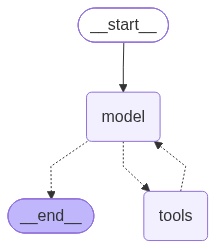

In [8]:
agent = create_agent(model, tools=[run_select], system_prompt=SYSTEM, checkpointer=InMemorySaver())

Image(agent.get_graph().draw_mermaid_png())

A função `show` roda um pedido em uma thread com `stream_mode="updates"` e imprime cada consulta, o começo da observação e a resposta final.

In [9]:
def show(request: str, thread_id: str) -> None:
    """Roda um pedido na thread e imprime as consultas e a resposta."""
    config = {"configurable": {"thread_id": thread_id}}
    for step in agent.stream({"messages": [HumanMessage(request)]}, config, stream_mode="updates"):
        for message in next(iter(step.values()))["messages"]:
            if message.type == "tool":
                print("   ", message.content[:70].replace("\n", " / "))
            elif message.tool_calls:
                print(*[call["args"]["query"] for call in message.tool_calls], sep="\n")
            else:
                print(message.content)

In [10]:
show("Quanto gastei na farmácia?", "t1")

SELECT DISTINCT seller FROM invoices WHERE seller LIKE '%farmacia%' OR seller LIKE '%farmácia%'
    seller / Farmacia Gaspar


SELECT SUM(total) as total_spent FROM invoices WHERE seller LIKE '%Farmacia Gaspar%'
    total_spent / 42.900000000000006


Você gastou um total de 42,90 euros na farmácia Farmacia Gaspar.


Com o esquema no prompt, a primeira consulta já usou os nomes certos de tabela e coluna. O modelo listou as grafias com `LIKE`, com e sem acento, encontrou uma loja só e somou as duas notas dela em 42,90 euros.

In [11]:
show("E o que eu comprei lá?", "t1")

SELECT name, quantity, price FROM products WHERE file IN (SELECT file FROM invoices WHERE seller LIKE '%Farmacia Gaspar%')
    name | quantity | price / Reumon Gel, 50 mg/g-60 g x 1 gel bisnaga | 1.0


Na farmácia Farmacia Gaspar, você comprou Reumon Gel, Isdin Foot Care Ureadin, Griponal e máscaras cirúrgicas.


O segundo pedido não diz de qual loja se trata, e o modelo resolveu "lá" pelo histórico da thread `t1`, que o checkpointer devolveu. A subconsulta ligou as duas tabelas pela coluna `file` e trouxe os produtos das duas notas.

## Várias consultas

O pedido abaixo tem duas partes, e a segunda depende da resposta da primeira: só depois de saber o ano de maior gasto dá para perguntar quais lojas pesaram nele. Cada consulta é uma volta do laço, e o modelo escreve a seguinte depois de ler o resultado da anterior.

In [12]:
show("Em que ano gastei mais, e quais lojas concentraram esse gasto?", "t2")

SELECT DISTINCT seller FROM invoices
    seller / Moinho Velho / RESTAURANTE MANUEL JU / Farmacia Gaspar / Pinço Doce -


SELECT strftime('%Y', date) AS year, SUM(total) AS total_spent FROM invoices GROUP BY year ORDER BY total_spent DESC LIMIT 1
    year | total_spent / 2019 | 615.8299999999999


SELECT DISTINCT seller FROM invoices WHERE strftime('%Y', date) = '2019'
    seller / JMTD FERRAGENS DO COMBROIDA / Dia Portugal * Sur. Soc. Unip., Lda


SELECT seller, SUM(total) AS total_spent FROM invoices WHERE strftime('%Y', date) = '2019' GROUP BY seller ORDER BY total_spent DESC LIMIT 3
    seller | total_spent / INTERMARCHE LAGOA PO PARTIDO CARVOEIRO | 224.2 / GA


Você gastou mais no ano de 2019, com os maiores gastos concentrados nas lojas INTERMARCHE LAGOA PO PARTIDO CARVOEIRO, GALPESTE, S.A., e IKEA Alfragide.


O laço deu quatro voltas: listar as lojas, somar por ano, olhar as lojas de 2019 e somar por loja dentro dele. O filtro por ano da terceira e da quarta consulta veio do resultado da segunda. O `GROUP BY` separou `IKEA Alfragide` de `IKEA ALFRAGIDE`, e juntas as duas notas somam 144,98 euros, o que põe a IKEA à frente da Galp.

## Conversa

O laço abaixo lê um pedido por vez com `input` e manda cada um para a mesma thread, então o agente lembra das perguntas anteriores. Uma linha vazia encerra. Pergunte, por exemplo, em que mês houve mais gasto ou quais notas ficaram com problema na extração.

In [13]:
def chat(thread_id: str) -> None:
    """Lê pedidos até uma linha vazia e manda cada um para a mesma thread."""
    while request := input("você: ").strip():
        show(request, thread_id)

In [ ]:
chat("conversa")